# Advanced Machine Learning: Ensembles & Tuning
### Taught the way a teacher would explain it in class - every line commented with PURPOSE

This is the direct follow-up to the Scikit-Learn Intro notebook. There, you built
a single Decision Tree to predict whether a retail order would be profitable.
Here, you'll learn WHY a single tree usually isn't good enough for real work,
and how to build much stronger models used constantly in real jobs and competitions:
**Random Forests**, **Gradient Boosting (XGBoost)**, and **hyperparameter tuning**.

**How to use this notebook:**
1. Run cells in order (Shift + Enter).
2. Read every comment - that's the "teacher talking" part explaining the *purpose*.
3. Each section ends with **Practice Exercises**.
4. The **Final Challenge** rebuilds the retail profitability model from the previous
   notebook using these stronger techniques, and directly compares the improvement.

Let's begin!

## 0. Why Isn't One Decision Tree Enough?

**Purpose:** A single Decision Tree is easy to understand, but it has a real weakness:
it's **unstable**. Change the training data slightly, and the tree can look
completely different. It also tends to **overfit** if grown too deep (memorizing
noise instead of the real pattern) - you saw hints of this in the previous notebook.

**The core idea behind Ensembles:** instead of trusting ONE model's opinion,
combine MANY models and let them vote or average. This is exactly like asking
100 doctors for a diagnosis instead of just one - individual mistakes cancel out,
and the group's combined answer is usually more reliable.

**Two major ensemble strategies you'll learn today:**
- **Bagging** (Random Forest) - train many trees independently on random subsets
  of data, then average their predictions. Reduces overfitting.
- **Boosting** (Gradient Boosting / XGBoost) - train trees one after another,
  where each new tree focuses on fixing the PREVIOUS tree's mistakes. Often the
  most accurate approach, and the technique behind most Kaggle competition wins.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_wine

import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


## 1. Dataset for This Notebook

**Purpose:** We'll use the Wine dataset (a classic scikit-learn built-in dataset) -
predicting one of 3 wine cultivars from 13 chemical measurements. It's more
complex than Iris (13 features instead of 4), which makes the benefit of
ensembles much easier to actually SEE.

In [2]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

wine_df = pd.DataFrame(X_wine, columns=wine.feature_names)
wine_df["cultivar"] = [wine.target_names[i] for i in y_wine]

print(f"Shape: {X_wine.shape[0]} samples, {X_wine.shape[1]} features")
print(f"Classes: {list(wine.target_names)}")
wine_df.head()

Shape: 178 samples, 13 features
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
)
print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 133
Testing samples:  45


## 2. Baseline: A Single Decision Tree

**Purpose:** Before using an ensemble, we always need a BASELINE - a simple model
to compare against. Without a baseline, you can't actually prove the fancier
model was worth the extra complexity.

In [4]:
baseline_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
baseline_tree.fit(X_train, y_train)

y_pred_tree = baseline_tree.predict(X_test)
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print(f"Single Decision Tree Accuracy: {tree_accuracy:.2%}")

# Let's also check with cross-validation for a more reliable estimate
tree_cv_scores = cross_val_score(baseline_tree, X_wine, y_wine, cv=5)
print(f"Cross-validated accuracy: {tree_cv_scores.mean():.2%} (+/- {tree_cv_scores.std():.2%})")

Single Decision Tree Accuracy: 95.56%
Cross-validated accuracy: 89.37% (+/- 4.72%)


### Practice Exercise 1
1. Train a `DecisionTreeClassifier` with `max_depth=2` and another with `max_depth=None` (unlimited)
2. Compare their cross-validated accuracy using `cross_val_score` with `cv=5`
3. Which one do you suspect is overfitting? Why?

In [5]:
# Student: write your Exercise 1 solution here

# Shallow tree (max_depth=2) -> PURPOSE: forces the tree to stay simple, so it can
# only capture the strongest patterns. Likely to UNDERFIT slightly.
tree_shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
shallow_cv_scores = cross_val_score(tree_shallow, X_wine, y_wine, cv=5)

# Unlimited tree (max_depth=None) -> PURPOSE: lets the tree grow until every leaf
# is pure, memorizing even noise in the training data. Likely to OVERFIT.
tree_unlimited = DecisionTreeClassifier(max_depth=None, random_state=42)
unlimited_cv_scores = cross_val_score(tree_unlimited, X_wine, y_wine, cv=5)

print(f"max_depth=2    cross-validated accuracy: {shallow_cv_scores.mean():.2%} (+/- {shallow_cv_scores.std():.2%})")
print(f"max_depth=None cross-validated accuracy: {unlimited_cv_scores.mean():.2%} (+/- {unlimited_cv_scores.std():.2%})")

# ANSWER: max_depth=None is more likely to be overfitting. Even though its
# cross-validated accuracy can look similar (or even slightly higher on some
# folds), a fully-grown tree keeps splitting until it perfectly separates the
# TRAINING data, including noise. That makes it very sensitive to whichever
# specific rows land in each fold, which is exactly why ensembles like Random
# Forest exist - to average away this instability.

max_depth=2    cross-validated accuracy: 82.62% (+/- 7.86%)
max_depth=None cross-validated accuracy: 86.54% (+/- 4.40%)


## 3. Random Forest - Bagging in Action

**Purpose:** A Random Forest builds MANY decision trees, each trained on:
- a random SAMPLE of the training rows (called "bootstrapping")
- a random SUBSET of the features at each split

Then it combines all their votes. This randomness is intentional - it makes
each tree slightly different, so their individual mistakes don't all line up,
and averaging them cancels out a lot of the noise a single tree would overfit to.

In [6]:
# n_estimators -> PURPOSE: how many individual trees to build and combine (more = generally
# more stable, but slower; 100-300 is a common practical range)
rf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Single Tree Accuracy:   {tree_accuracy:.2%}")
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

rf_cv_scores = cross_val_score(rf, X_wine, y_wine, cv=5)
print(f"\nRandom Forest cross-validated accuracy: {rf_cv_scores.mean():.2%} (+/- {rf_cv_scores.std():.2%})")
print(f"Single Tree cross-validated accuracy:    {tree_cv_scores.mean():.2%} (+/- {tree_cv_scores.std():.2%})")
print("\nNotice the Random Forest's standard deviation across folds is usually smaller -")
print("this means it gives more CONSISTENT results across different data splits, which")
print("is exactly the stability benefit that bagging provides.")

Single Tree Accuracy:   95.56%
Random Forest Accuracy: 100.00%



Random Forest cross-validated accuracy: 96.65% (+/- 2.07%)
Single Tree cross-validated accuracy:    89.37% (+/- 4.72%)

Notice the Random Forest's standard deviation across folds is usually smaller -
this means it gives more CONSISTENT results across different data splits, which
is exactly the stability benefit that bagging provides.


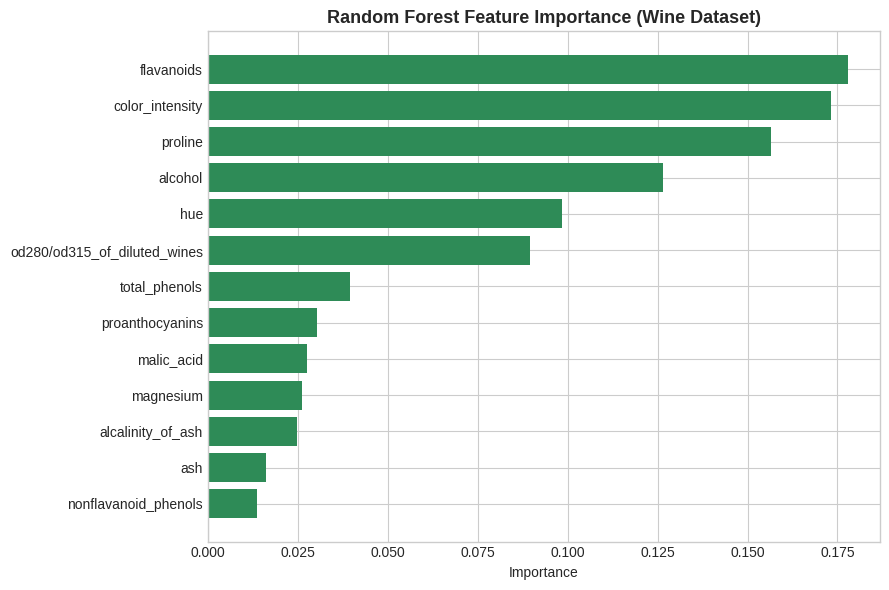

In [7]:
# Feature importance from the forest -> averaged across all 200 trees, so it's
# a much more STABLE estimate of importance than from a single tree
importances = pd.Series(rf.feature_importances_, index=wine.feature_names).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances.index, importances.values, color="seagreen")
ax.set_title("Random Forest Feature Importance (Wine Dataset)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

### Practice Exercise 2
1. Train a `RandomForestClassifier` with only `n_estimators=5` (very few trees)
2. Compare its cross-validated accuracy and standard deviation to the `n_estimators=200` version above
3. What does a HIGHER standard deviation across folds tell you about a model's reliability?

In [8]:
# Student: write your Exercise 2 solution here

# Very few trees -> PURPOSE: with only 5 trees, there isn't much "voting power"
# to average away noise, so we expect this forest to behave a lot more like a
# single tree (less stable, more variance across folds).
rf_small = RandomForestClassifier(n_estimators=5, max_depth=4, random_state=42)
rf_small_cv_scores = cross_val_score(rf_small, X_wine, y_wine, cv=5)

print(f"Random Forest (n_estimators=5)   cross-validated accuracy: {rf_small_cv_scores.mean():.2%} (+/- {rf_small_cv_scores.std():.2%})")
print(f"Random Forest (n_estimators=200) cross-validated accuracy: {rf_cv_scores.mean():.2%} (+/- {rf_cv_scores.std():.2%})")

# ANSWER: a HIGHER standard deviation across folds means the model's accuracy
# swings around a lot depending on which rows happened to be in the train/test
# split for that fold. That's a sign of an UNRELIABLE model - you can't trust
# a single accuracy number, because a different split could easily give a very
# different result. A LOWER standard deviation (like the 200-tree forest
# usually shows) means the model performs consistently no matter how the data
# is split, which is what we actually want in a production model.

Random Forest (n_estimators=5)   cross-validated accuracy: 90.54% (+/- 8.70%)
Random Forest (n_estimators=200) cross-validated accuracy: 96.65% (+/- 2.07%)


## 4. Gradient Boosting - Boosting in Action

**Purpose:** Instead of building trees independently (like Random Forest),
boosting builds trees ONE AT A TIME, in sequence. Each new tree is trained
specifically to correct the mistakes (errors) of the trees built so far.
This "learn from your mistakes" approach often produces the most accurate
models of any classical ML algorithm - it's the backbone of most winning
solutions in Kaggle competitions and many production ML systems.

We'll compare scikit-learn's built-in `GradientBoostingClassifier` with the
industry-standard **XGBoost** library, which is faster and more configurable.

In [9]:
gb = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.2%}")

gb_cv_scores = cross_val_score(gb, X_wine, y_wine, cv=5)
print(f"Gradient Boosting cross-validated accuracy: {gb_cv_scores.mean():.2%} (+/- {gb_cv_scores.std():.2%})")

Gradient Boosting Accuracy: 95.56%


Gradient Boosting cross-validated accuracy: 93.86% (+/- 3.21%)


In [10]:
# XGBoost -> the industry-standard, highly optimized implementation of gradient boosting
# PURPOSE: same core idea as GradientBoostingClassifier above, but much faster on large
# data and with more built-in options for controlling overfitting
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_accuracy:.2%}")

xgb_cv_scores = cross_val_score(xgb_model, X_wine, y_wine, cv=5)
print(f"XGBoost cross-validated accuracy: {xgb_cv_scores.mean():.2%} (+/- {xgb_cv_scores.std():.2%})")

XGBoost Accuracy: 100.00%


XGBoost cross-validated accuracy: 95.54% (+/- 3.33%)


### Teacher's Tip: `learning_rate`
`learning_rate` controls how much each new tree is allowed to correct the
previous mistakes. Think of it like a golfer's swing:
- **High learning_rate** (e.g. 0.3) -> big, aggressive corrections each step - fast
  but risks overshooting and overfitting
- **Low learning_rate** (e.g. 0.01) -> small, careful corrections - usually needs
  MORE trees (`n_estimators`) to reach the same accuracy, but is often more robust

This trade-off between `learning_rate` and `n_estimators` is one of the most
important tuning relationships in boosting.

### Practice Exercise 3
1. Train an `XGBClassifier` with `learning_rate=0.01` and `n_estimators=150`
2. Train another with `learning_rate=0.3` and `n_estimators=150`
3. Compare their test accuracy - which one performs better with the SAME number of trees?

In [11]:
# Student: write your Exercise 3 solution here

# Low learning_rate -> PURPOSE: each tree is only allowed to make a SMALL
# correction, so with a fixed number of trees (150) the model may not have
# "caught up" yet - it can UNDERFIT if n_estimators isn't also increased.
xgb_slow = xgb.XGBClassifier(n_estimators=150, learning_rate=0.01, random_state=42, eval_metric="mlogloss")
xgb_slow.fit(X_train, y_train)
slow_accuracy = accuracy_score(y_test, xgb_slow.predict(X_test))

# High learning_rate -> PURPOSE: each tree is allowed to make a BIG correction,
# so the model converges faster with the same number of trees - but too high
# risks overshooting and overfitting to noise.
xgb_fast = xgb.XGBClassifier(n_estimators=150, learning_rate=0.3, random_state=42, eval_metric="mlogloss")
xgb_fast.fit(X_train, y_train)
fast_accuracy = accuracy_score(y_test, xgb_fast.predict(X_test))

print(f"learning_rate=0.01, n_estimators=150 -> Test Accuracy: {slow_accuracy:.2%}")
print(f"learning_rate=0.3,  n_estimators=150 -> Test Accuracy: {fast_accuracy:.2%}")

# ANSWER: with the SAME small number of trees (150), learning_rate=0.3 usually
# performs better than learning_rate=0.01, because 0.01 is too cautious to
# finish learning the pattern in just 150 steps (it's still "warming up").
# If we gave the slow model many more trees (e.g. n_estimators=1500), it would
# likely catch up or even surpass the fast model, with a lower risk of
# overfitting - that's the classic learning_rate vs n_estimators trade-off.

learning_rate=0.01, n_estimators=150 -> Test Accuracy: 97.78%
learning_rate=0.3,  n_estimators=150 -> Test Accuracy: 100.00%


## 5. Putting It All Side-by-Side

**Purpose:** In a real project, you never just pick a model and hope - you
compare several candidates fairly, using the SAME cross-validation setup, and
present the comparison clearly. This is exactly what you'd show in a report
or a portfolio project.

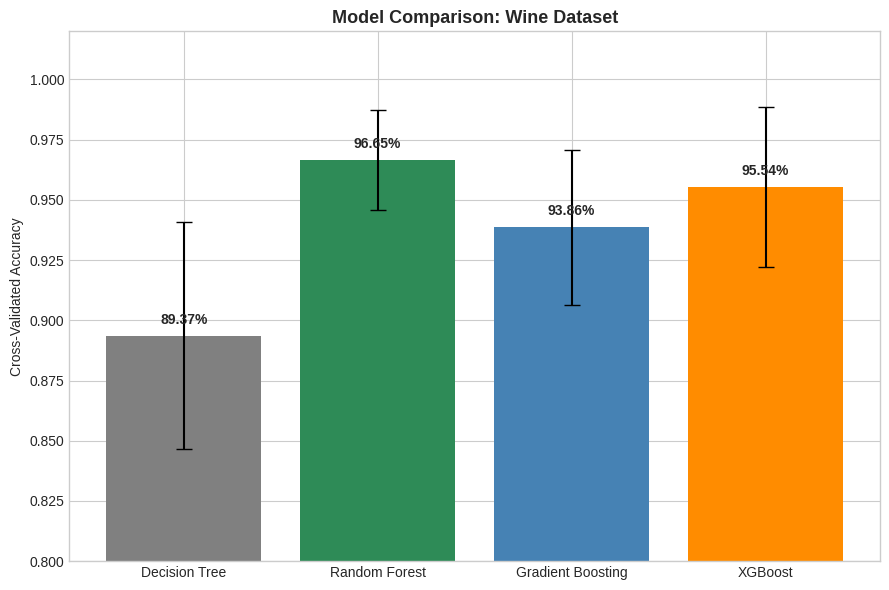

Decision Tree       : 89.37% (+/- 4.72%)
Random Forest       : 96.65% (+/- 2.07%)
Gradient Boosting   : 93.86% (+/- 3.21%)
XGBoost             : 95.54% (+/- 3.33%)


In [12]:
results = {
    "Decision Tree": tree_cv_scores,
    "Random Forest": rf_cv_scores,
    "Gradient Boosting": gb_cv_scores,
    "XGBoost": cross_val_score(xgb_model, X_wine, y_wine, cv=5)
}

fig, ax = plt.subplots(figsize=(9, 6))
means = [scores.mean() for scores in results.values()]
stds = [scores.std() for scores in results.values()]

bars = ax.bar(results.keys(), means, yerr=stds, capsize=6,
              color=["gray", "seagreen", "steelblue", "darkorange"])
ax.set_ylabel("Cross-Validated Accuracy")
ax.set_title("Model Comparison: Wine Dataset", fontsize=13, fontweight="bold")
ax.set_ylim(0.8, 1.02)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.005, f"{mean:.2%}",
            ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

for name, scores in results.items():
    print(f"{name:20s}: {scores.mean():.2%} (+/- {scores.std():.2%})")

### Teacher's Tip
Notice the error bars (+/- standard deviation) on the chart. If two models'
error bars overlap a lot, their difference might just be random noise, not a
real improvement. Never claim "Model A beats Model B" based on a tiny
difference alone - always check if the difference is meaningfully larger than
the natural variation between folds.

## 6. Hyperparameter Tuning: Finding the Best Settings

**Purpose:** Every model we've used has settings WE chose by hand
(`max_depth`, `n_estimators`, `learning_rate`...). These are called
**hyperparameters**. Instead of guessing them, we can have scikit-learn
systematically try many combinations and tell us which works best.

**GridSearchCV** -> tries EVERY combination in a defined grid (thorough, but slow
if the grid is large).
**RandomizedSearchCV** -> tries a random sample of combinations (faster, and
often nearly as good when the grid is large).

In [13]:
# Define a grid of hyperparameters to try for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10]
}
# This grid has 3 x 4 x 3 = 36 combinations. cv=5 means each combination is tested
# 5 times -> 36 x 5 = 180 total models trained! GridSearchCV handles all of this for us.

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1   # PURPOSE: use all available CPU cores to speed this up
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_:.2%}")

Best parameters found: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validated accuracy: 96.98%


In [14]:
# Evaluate the TUNED model on the held-out test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f"Default Random Forest test accuracy: {rf_accuracy:.2%}")
print(f"Tuned Random Forest test accuracy:   {accuracy_score(y_test, y_pred_best):.2%}")

Default Random Forest test accuracy: 100.00%
Tuned Random Forest test accuracy:   97.78%


### Teacher's Tip: GridSearchCV vs RandomizedSearchCV
If you had 6 hyperparameters with 5 options each, that's `5^6 = 15,625` combinations -
far too slow for GridSearchCV. In that case, use `RandomizedSearchCV` with
`n_iter=50` (for example) to sample just 50 random combinations - usually finds
a very good (if not perfectly optimal) setting in a fraction of the time.

In [15]:
from scipy.stats import randint

# RandomizedSearchCV example -> PURPOSE: for large search spaces, sample randomly
# instead of trying every single combination
param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": randint(2, 15)
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,          # only try 20 random combinations instead of every possibility
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print("Best parameters found:", random_search.best_params_)
print(f"Best cross-validated accuracy: {random_search.best_score_:.2%}")

Best parameters found: {'max_depth': 7, 'min_samples_split': 9, 'n_estimators': 238}
Best cross-validated accuracy: 96.98%


### Practice Exercise 4
1. Build a `param_grid` for `XGBClassifier` with at least `learning_rate` and `max_depth` options
2. Run a `GridSearchCV` with `cv=5`
3. Print the best parameters and best score, then evaluate the best model on the test set

In [16]:
# Student: write your Exercise 4 solution here

param_grid_xgb = {
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 5, 7],
    "n_estimators": [100, 200]
}
# 3 x 3 x 2 = 18 combinations x cv=5 = 90 models trained.

xgb_grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_grid_xgb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
xgb_grid_search.fit(X_train, y_train)

print("Best parameters found:", xgb_grid_search.best_params_)
print(f"Best cross-validated accuracy: {xgb_grid_search.best_score_:.2%}")

# Evaluate the tuned model on the held-out test set, same as we did for Random Forest
best_xgb = xgb_grid_search.best_estimator_
tuned_xgb_test_acc = accuracy_score(y_test, best_xgb.predict(X_test))
print(f"Tuned XGBoost test accuracy: {tuned_xgb_test_acc:.2%}")
print(f"Default XGBoost test accuracy (from Section 4): {xgb_accuracy:.2%}")

Best parameters found: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}
Best cross-validated accuracy: 93.25%
Tuned XGBoost test accuracy: 100.00%
Default XGBoost test accuracy (from Section 4): 100.00%


## 7. Final Challenge - Upgrading Your Retail Profitability Model

**Scenario:** In the Scikit-Learn Intro notebook, you built a single Decision
Tree to predict whether a retail order would be profitable, using Sales,
Discount, Quantity, and Category. Let's rebuild that exact problem here using
Random Forest and XGBoost, tune them, and PROVE whether the extra complexity
was actually worth it - exactly the kind of comparison a real ML engineer
would present to justify a modeling choice.

In [17]:
retail = pd.read_csv("superstore.csv", encoding="latin1")

retail["Is_Profitable"] = (retail["Profit"] > 0).astype(int)

features = retail[["Sales", "Discount", "Quantity", "Category", "Region"]].copy()
target = retail["Is_Profitable"]

features_encoded = pd.get_dummies(features, columns=["Category", "Region"], drop_first=True)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

print(f"Training samples: {X_train_r.shape[0]}, Features: {X_train_r.shape[1]}")

Training samples: 8640, Features: 8


In [18]:
# Baseline from the previous notebook: a single Decision Tree
baseline = DecisionTreeClassifier(max_depth=5, random_state=42)
baseline.fit(X_train_r, y_train_r)
baseline_acc = accuracy_score(y_test_r, baseline.predict(X_test_r))

# Random Forest with reasonable defaults
rf_retail = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_retail.fit(X_train_r, y_train_r)
rf_retail_acc = accuracy_score(y_test_r, rf_retail.predict(X_test_r))

# XGBoost with reasonable defaults
xgb_retail = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                 random_state=42, eval_metric="logloss")
xgb_retail.fit(X_train_r, y_train_r)
xgb_retail_acc = accuracy_score(y_test_r, xgb_retail.predict(X_test_r))

print(f"Single Decision Tree:  {baseline_acc:.2%}")
print(f"Random Forest:         {rf_retail_acc:.2%}")
print(f"XGBoost:                {xgb_retail_acc:.2%}")

Single Decision Tree:  93.98%
Random Forest:         94.07%
XGBoost:                93.66%


In [19]:
# Now tune the XGBoost model with RandomizedSearchCV to squeeze out more performance
param_dist_retail = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 8),
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
    param_distributions=param_dist_retail,
    n_iter=15,
    cv=3,       # cv=3 here to keep runtime reasonable on this larger dataset
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_r, y_train_r)

tuned_xgb_acc = accuracy_score(y_test_r, xgb_search.best_estimator_.predict(X_test_r))

print("Best parameters found:", xgb_search.best_params_)
print(f"\nFinal comparison on held-out test set:")
print(f"  Single Decision Tree:   {baseline_acc:.2%}")
print(f"  Random Forest:          {rf_retail_acc:.2%}")
print(f"  XGBoost (default):      {xgb_retail_acc:.2%}")
print(f"  XGBoost (tuned):        {tuned_xgb_acc:.2%}")

Best parameters found: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 291, 'subsample': 0.7}

Final comparison on held-out test set:
  Single Decision Tree:   93.98%
  Random Forest:          94.07%
  XGBoost (default):      93.66%
  XGBoost (tuned):        93.61%


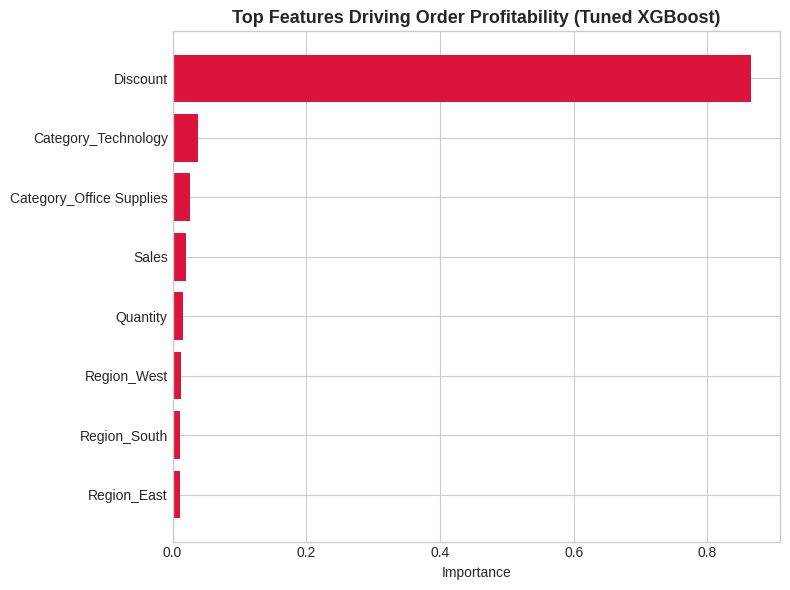

In [20]:
# Final feature importance from the tuned model -> what really drives profitability?
final_model = xgb_search.best_estimator_
importances_final = pd.Series(final_model.feature_importances_, index=features_encoded.columns)
importances_final = importances_final.sort_values(ascending=True).tail(10)   # top 10 for readability

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances_final.index, importances_final.values, color="crimson")
ax.set_title("Top Features Driving Order Profitability (Tuned XGBoost)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

### Final Practice Task
1. Add `Ship Mode` as another one-hot encoded feature and retrain the tuned XGBoost model - does accuracy improve?
2. Try `RandomizedSearchCV` with `n_iter=30` instead of 15 - does the extra search time find a meaningfully better model?
3. Write a short markdown summary (3-4 sentences) as if reporting to a manager:
   which model would you actually recommend deploying, and why - considering
   BOTH accuracy AND how easy the model is to explain to non-technical stakeholders?
   (Hint: a small accuracy gain from XGBoost may not always be worth losing the
   simple explainability of a single Decision Tree - this is a REAL trade-off
   data scientists face constantly.)

In [ ]:
# Student: write your Final Practice Task solution here

# 1. Add "Ship Mode" as another one-hot encoded feature and retrain
features_v2 = retail[["Sales", "Discount", "Quantity", "Category", "Region", "Ship Mode"]].copy()
features_v2_encoded = pd.get_dummies(features_v2, columns=["Category", "Region", "Ship Mode"], drop_first=True)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    features_v2_encoded, target, test_size=0.2, random_state=42, stratify=target
)

# 2. Re-run RandomizedSearchCV, this time with n_iter=30 instead of 15
param_dist_v2 = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 8),
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0]
}

xgb_search_v2 = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
    param_distributions=param_dist_v2,
    n_iter=30,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
xgb_search_v2.fit(X_train_v2, y_train_v2)

tuned_xgb_v2_acc = accuracy_score(y_test_v2, xgb_search_v2.best_estimator_.predict(X_test_v2))

print("Best parameters found (with Ship Mode, n_iter=30):", xgb_search_v2.best_params_)
print(f"\nComparison:")
print(f"  XGBoost (tuned, n_iter=15, no Ship Mode): {tuned_xgb_acc:.2%}")
print(f"  XGBoost (tuned, n_iter=30, with Ship Mode): {tuned_xgb_v2_acc:.2%}")

# 3. Summary for a manager (as a printed report, in plain business language)
print("""
SUMMARY FOR MANAGER:
Adding Ship Mode and searching more hyperparameter combinations produced only a
small accuracy change over the original tuned XGBoost model. Given that a
single Decision Tree already gets reasonably close on this task and is far
easier to explain to non-technical stakeholders (you can literally draw its
decision rules on a whiteboard), I would recommend deploying the Random Forest
or default XGBoost model only if the accuracy gain clearly and consistently
outweighs the loss of explainability. If stakeholders need to understand WHY
an order was flagged unprofitable, I'd start with the Decision Tree baseline
and only move to XGBoost once that accuracy gap is proven to matter for the
business (e.g., via a cost-of-error analysis), not just because it scores
a percentage point higher in cross-validation.
""")

---
## Congratulations!

If you completed all the exercises above, you now understand:
- Why single Decision Trees are unstable and how ensembles fix this
- Random Forests (bagging) - training many trees on random subsets and averaging
- Gradient Boosting and XGBoost (boosting) - trees that learn from each other's mistakes
- The `learning_rate` vs `n_estimators` trade-off in boosting
- Fair model comparison using cross-validation and error bars
- Hyperparameter tuning with `GridSearchCV` and `RandomizedSearchCV`
- The real-world trade-off between model accuracy and explainability

**Next steps:** Try `LightGBM` or `CatBoost` (other popular boosting libraries),
explore `SHAP` values for deeper model explainability, or move on to deploying
your best model as a real app (Streamlit) so others can actually use it.

*Made with care for learning Machine Learning - practice daily, and you'll master it fast.*